In [0]:
%pip install openpyxl

In [0]:
import pandas as pd

file_path = "/Volumes/boe/default/boe_project_files/boe-nmg-household-survey-data.xlsx"

# Extracting the 2024 data
df_2024 = pd.read_excel(file_path, sheet_name="2024")
df_2024['survey_year'] = 2024

# Extracting the March 2025 data
df_2025 = pd.read_excel(file_path, sheet_name="March 2025")
df_2025['survey_year'] = 2025

# Convert to Spark and Union
# allowMissingColumns handles cases where 2025 might have new survey questions
spark_2024 = spark.createDataFrame(df_2024.astype(str)) 
spark_2025 = spark.createDataFrame(df_2025.astype(str))

bronze_df = spark_2024.unionByName(spark_2025, allowMissingColumns=True)

# Save as Bronze Table
bronze_df.write.mode("overwrite").saveAsTable("boe.default.bronze_household_data")

print("Success! Bronze table ready.")

Success! Bronze table ready.


In [0]:
%sql
SELECT *
FROM boe.default.bronze_household_data
LIMIT 5;

we_factor,fgenage_1,dage,dregion,fgen,qhousing,dhousing,qual,be2afree_1,be2afree_dk_1,be2afree_dk_2,be2a,fbe03,be04free_1,be04free_dk_1,be04free_dk_2,be04,be07free_1,be07free_dk_1,be07free_dk_2,be07,be08free_1,be08free_dk_1,be08free_dk_2,be08,be09,bd09_hidden,boe47,boe50year,boe50_dk_1,boe50_dk_2,boe50,be13,qbe17free_1,qbe17free_dk_1,qbe17free_dk_2,qbe17,be23,boe39,boe55,bod55,qbe22b,be22bb_1,be22bb_2,be22bb_3,be22bb_4,be22bb_5,be22bb_6,be22bb_7,be22bb_8,be22bb_9,be31e,qregion,nochildren,adultworkingstatus_1,adultworkingstatus_2,adultworkingstatus_3,adultworkingstatus_4,adultworkingstatus_5,adultworkingstatus_6,adultworkingstatus_7,adultworkingstatus_8,adultworkingstatus_9,boe39a_1,boe39a_2,boe39a_3,boe57,boe60,boe65afree_1,boe65afree_dk_1,boe65afree_dk_2,boe65a,otheradults,typeresponse_1,typeresponse_2,typeresponse_3,qincomefreev2_n_1,qincomefreev2_n_2,qincomefreev2_n_3,qincomefreev2_dk_1,qincomefreev2_dk_2,qincomefreev2_dk_3,qincomefreev2_ps_1,qincomefreev2_ps_2,qincomefreev2_ps_3,qincomev2_1_1,qincomev2_1_2,qincomev2_1_3,uq03,fq01,fq02,fq03,spq01free_1,spq01free_dk_1,spq01free_dk_2,spq02,spq03,mq01,mq02,mq03,mq04,mq06,mq07,mq08,hincomev2_1,hincomev2_2,hincomev2_3,incomev2comb,be44_1,be44_2,be44_3,be44_4,be44_5,be44_6,boe60a,boe62a,boe63a_1,boe63a_2,boe63a_3,boe63a_4,boe63a_5,boe63a_9,boe63a_6,boe63a_7,boe63a_8,boe61a,boe64a_1,boe64a_2,boe64a_3,boe64a_4,boe64a_5,boe64a_6,boe64a_7,boe64a_8,boe64a_9,boe64a_10,boe64a_11,boe64a_12,boe82year,boe82_dk_1,boe82_dk_2,boe82,boe86_1,boe86_2,boe86_3,boe86_4,boe86_5,boe86_6,boe86_7,boe86_8,boe86_9,boe86_10,boe86_11,boe86_16,boe86_12,boe86_13,boe86_14,uq04_1,uq04_2,uq04_3,uq04_4,uq04_5,uq04_6,uq04_7,uq04_8,uq04_9,uq04_10,uq04_11,uq04_16,uq04_12,uq04_13,uq04_14,spq07free_1,spq07free_dk_1,spq07free_dk_2,spq07,mq08b,industry,combincome,op1,op2,boec11b,boec11afree_1,boec11afree_dk_1,boec11afree_dk_2,boec11a,sc1_1,sc1_2,sc1_3,sc1_4,sc1_5,sc1_6,sc1_7,sc2,sc3,socialgrade,dsocialgrade,mthincome,ncs1,qincomefreev2_nre_1,qincomefreev2_nre_2,qincomefreev2_nre_3,qincomefreev2_dkre_1,qincomefreev2_dkre_2,qincomefreev2_dkre_3,qincomefreev2_psre_1,qincomefreev2_psre_2,qincomefreev2_psre_3,qincomefreev2_totalre,dincomev2re_1,dincomev2re_2,dincomev2re_3,qincomev2_1re_1,qincomev2_1re_2,qincomev2_1re_3,hincomev2re_1,hincomev2re_2,hincomev2re_3,incomev2combre,combincomere,be08freere_1,be08free_dkre_1,be08free_dkre_2,be08re,overallincomecomb,overallcombincome,overallbe08,totaldebt,nds1,nds2,bd400,be400free_1,be400free_dk_1,be400free_dk_2,be400,be401free_1,be401free_dk_1,be401free_dk_2,be401,recent_workingstatus,drecent,adultworkingstatus_11,boe91free_1,boe91free_dk_1,boe91free_dk_2,boe92free_1,boe92free_dk_1,boe92free_dk_2,cv1081,nobedrooms,spq01bfree_1,spq01bfree_dk_1,spq01bfree_dk_2,spq03b_1,spq03b_2,spq03b_3,spq03b_5,spq03b_4,spq03b_6,spq03b_7,bc2_1,bc2_2,bc2_3,bc2_4,bc2_5,bc2_6,bc2_7,bc2_8,bc2_9,bc2_990,bc2_980,bc10a,bc10bfree_1,bc10bfree_dk_1,bc10bfree_dk_2,bc10c,bc12afree_1,bc12afree_dk_1,bc12afree_dk_2,bc12b,be17afree_1,be17afree_dk_1,be17afree_dk_2,be17a_bands,be17bfree_1,be17bfree_dk_1,be17bfree_dk_2,be17b_bands,fq01b_1,fq01b_3,fq01b_4,fq01b_5,fq01b_6,fq01b_7,fq01b_8,fq01b_9,fq01b_10,fq01b_11,fq01b_12,fq01b_13,sv11,sv11a_16,sv11a_17,sv11a_4,sv11a_6,sv11a_8,sv11a_18,sv11a_19,sv11a_15,sv11a_96,sv11a_97,sv11b_1,sv11b_2,sv11b_3,sv11b_11,sv11b_6,sv11b_12,sv11b_10,sv11b_96,sv11b_97,bod54r,boe59r_15,boe59r_2,boe59r_16,boe59r_3,boe59r_5,boe59r_6,boe59r_7,boe59r_8,boe59r_9,boe59r_13,boe59r_10,boe59r_14,boe59r_11,boe59r_12,boe54rfree_1,boe54rfree_dk_1,boe54rfree_dk_2,boe54rb,qbe15a_12,qbe15a_13,qbe15a_3,qbe15a_16,qbe15a_17,qbe15a_6,qbe15a_5,qbe15a_7,qbe15a_15,qbe15a_11,qbe15a_14,qbe15a_9,qbe15a_10,qbe15a_97,qbe15a_96,boe97afree_n_12,boe97afree_n_13,boe97afree_n_3,boe97afree_n_16,boe97afree_n_17,boe97afree_n_6,boe97afree_n_5,boe97afree_n_7,boe97afree_n_99,boe97afree_dk_12,boe97afree_dk_13,boe97afree_dk_3,boe97afree_dk_16,boe97afree_dk_17,boe97afree_dk_6,boe97afree_dk_5,boe97afree_dk_7,boe97afree_dk_99,boe97afre

In [0]:
%sql
CREATE OR REPLACE TABLE boe.default.silver_household_finances (
  -- Identifiers
  survey_year INT,
  we_factor DOUBLE,
  -- Income
  hh_total_income DOUBLE,
  main_earner_income DOUBLE,
  -- Debt & Assets
  hh_total_debt DECIMAL(18,2),
  hh_total_savings DECIMAL(18,2),
  -- Housing
  housing_status STRING,
  monthly_mortgage_payment DECIMAL(18,2),
  monthly_rent_payment DECIMAL(18,2),
  mortgage_rate_type STRING,
  -- Stress & Behavior
  financial_stress_status STRING,
  bill_payment_struggle STRING,
  consumption_change_pct DOUBLE,
  -- Expectations & Demographics
  income_growth_expectations STRING,
  age_group STRING,
  region STRING,
  employment_status STRING,
  number_of_children INT,
  social_grade STRING
) USING DELTA;

In [0]:
%sql
INSERT OVERWRITE boe.default.silver_household_finances
WITH raw_prep AS (
  SELECT 
    survey_year,
    -- Using TRY_CAST(NULLIF(...)) to handle 'nan' and decimals like '9.0'
    TRY_CAST(NULLIF(qincomev2_1_1, 'nan') AS DOUBLE) as q1,
    TRY_CAST(NULLIF(qincomev2_1_2, 'nan') AS DOUBLE) as q2,
    TRY_CAST(NULLIF(qincomev2_1_3, 'nan') AS DOUBLE) as q3,
    TRY_CAST(NULLIF(totaldebt, 'nan') AS DECIMAL(18,2)) as raw_debt,
    TRY_CAST(NULLIF(be07, 'nan') AS DECIMAL(18,2)) as raw_savings, -- Swapped to be07
    TRY_CAST(NULLIF(mq01, 'nan') AS DECIMAL(18,2)) as raw_mortgage,
    TRY_CAST(NULLIF(be04, 'nan') AS DECIMAL(18,2)) as raw_rent,
    TRY_CAST(NULLIF(be13, 'nan') AS DOUBLE) as raw_cons_change,
    TRY_CAST(NULLIF(we_factor, 'nan') AS DOUBLE) as weight,
    TRY_CAST(NULLIF(be09, 'nan') AS INT) as stress_code,
    TRY_CAST(NULLIF(boec11a, 'nan') AS INT) as bill_code, -- Mapping to bill struggle
    TRY_CAST(NULLIF(nochildren, 'nan') AS INT) as kids,
    dage, dregion, qhousing, mq02, qbe17, socialgrade, recent_workingstatus
  FROM boe.default.bronze_household_data
),
income_mapping AS (
  SELECT 
    *,
    -- Full 17-band Stata logic
    CASE WHEN q1 = 1 THEN 0 WHEN q1 = 2 THEN 1250 WHEN q1 = 3 THEN 3500 WHEN q1 = 4 THEN 5500 WHEN q1 = 5 THEN 7000 WHEN q1 = 6 THEN 8500 WHEN q1 = 7 THEN 10500 WHEN q1 = 8 THEN 12500 WHEN q1 = 9 THEN 14500 WHEN q1 = 10 THEN 16500 WHEN q1 = 11 THEN 21250 WHEN q1 = 12 THEN 30000 WHEN q1 = 13 THEN 40000 WHEN q1 = 14 THEN 50000 WHEN q1 = 15 THEN 65000 WHEN q1 = 16 THEN 87500 WHEN q1 = 17 THEN 125000 ELSE 0 END AS main_inc,
    CASE WHEN q2 = 1 THEN 0 WHEN q2 = 2 THEN 1250 WHEN q2 = 3 THEN 3500 WHEN q2 = 4 THEN 5500 WHEN q2 = 5 THEN 7000 WHEN q2 = 6 THEN 8500 WHEN q2 = 7 THEN 10500 WHEN q2 = 8 THEN 12500 WHEN q2 = 9 THEN 14500 WHEN q2 = 10 THEN 16500 WHEN q2 = 11 THEN 21250 WHEN q2 = 12 THEN 30000 WHEN q2 = 13 THEN 40000 WHEN q2 = 14 THEN 50000 WHEN q2 = 15 THEN 65000 WHEN q2 = 16 THEN 87500 WHEN q2 = 17 THEN 125000 ELSE 0 END AS partner_inc,
    CASE WHEN q3 = 1 THEN 0 WHEN q3 = 2 THEN 1250 WHEN q3 = 3 THEN 3500 WHEN q3 = 4 THEN 5500 WHEN q3 = 5 THEN 7000 WHEN q3 = 6 THEN 8500 WHEN q3 = 7 THEN 10500 WHEN q3 = 8 THEN 12500 WHEN q3 = 9 THEN 14500 WHEN q3 = 10 THEN 16500 WHEN q3 = 11 THEN 21250 WHEN q3 = 12 THEN 30000 WHEN q3 = 13 THEN 40000 WHEN q3 = 14 THEN 50000 WHEN q3 = 15 THEN 65000 WHEN q3 = 16 THEN 87500 WHEN q3 = 17 THEN 125000 ELSE 0 END AS other_inc
  FROM raw_prep
)
SELECT 
    survey_year,
    weight,
    (main_inc + partner_inc + other_inc) AS hh_total_income,
    main_inc,
    raw_debt,
    raw_savings,
    qhousing,
    raw_mortgage,
    raw_rent,
    mq02,
    CASE WHEN stress_code = 1 THEN 'High Stress' WHEN stress_code = 2 THEN 'Moderate Stress' ELSE 'Stable' END,
    CASE WHEN bill_code = 1 THEN 'Struggling' ELSE 'Keeping Up' END,
    raw_cons_change,
    qbe17,
    dage,
    dregion,
    recent_workingstatus,
    kids,
    socialgrade
FROM income_mapping
WHERE main_inc > 0 OR raw_debt > 0 OR raw_savings > 0;

num_affected_rows,num_inserted_rows
7988,7988


In [0]:
%sql
SELECT *
FROM boe.default.silver_household_finances
LIMIT 1

survey_year,we_factor,hh_total_income,main_earner_income,hh_total_debt,hh_total_savings,housing_status,monthly_mortgage_payment,monthly_rent_payment,mortgage_rate_type,financial_stress_status,bill_payment_struggle,consumption_change_pct,income_growth_expectations,age_group,region,employment_status,number_of_children,social_grade
2024,0.85775709,0.0,0.0,160.00,null,2,14.00,17.00,14,Stable,Keeping Up,null,9.0,5,4,7,0,4


In [0]:
%sql
CREATE OR REPLACE VIEW boe.default.gold_household_insights AS
SELECT 
    survey_year,
    we_factor,
    
    -- 1. DEMOGRAPHICS (The 'Who')
    CASE 
        WHEN age_group = '1' THEN '18-24'
        WHEN age_group = '2' THEN '25-34'
        WHEN age_group = '3' THEN '35-44'
        WHEN age_group = '4' THEN '45-54'
        WHEN age_group = '5' THEN '55-64'
        WHEN age_group = '6' THEN '65+'
        ELSE 'Unknown'
    END AS age_bracket,

    CASE 
        WHEN region = '1' THEN 'North'
        WHEN region = '2' THEN 'Midlands'
        WHEN region = '3' THEN 'East'
        WHEN region = '4' THEN 'London'
        WHEN region = '5' THEN 'South East'
        WHEN region = '6' THEN 'South West'
        WHEN region = '7' THEN 'Wales/Scotland/NI'
        ELSE 'Other'
    END AS uk_region,

    CASE 
        WHEN housing_status = '1' THEN 'Owner (Mortgage)'
        WHEN housing_status = '2' THEN 'Owner (Outright)'
        WHEN housing_status = '3' THEN 'Renting (Private)'
        WHEN housing_status = '4' THEN 'Renting (Social)'
        ELSE 'Other'
    END AS tenure,

    -- 2. FINANCIALS (The 'What')
    hh_total_income,
    hh_total_debt,
    hh_total_savings,
    
    -- 3. CALCULATED METRICS (The 'So What?')
    -- Debt-to-Income Ratio (Safely handling zero income)
    CASE 
        WHEN hh_total_income > 0 THEN ROUND(hh_total_debt / hh_total_income, 2)
        ELSE NULL 
    END AS debt_to_income_ratio,

    financial_stress_status,
    bill_payment_struggle,
    employment_status

FROM boe.default.silver_household_finances;

In [0]:
%sql
-- PROJECT: UK Household Financial Resilience Analysis
-- DATA SOURCE: Bank of England NMG Survey (2024-2025)
-- OBJECTIVE: Quantify objective financial vulnerability across UK demographics.


SELECT 
    -- 1. survey_year: The timeframe of the data (2024 vs 2025). 
    -- Allows tracking if the UK is getting more or less stressed over time.
    survey_year,

    -- 2. age_bracket: The demographic slice. 
    -- Crucial for identifying if "Gen Z" or "Pensioners" are bearing the brunt of the crisis.
    age_bracket,

    -- 3. tenure: The housing status (e.g., Social Renter vs. Homeowner). 
    -- This is often the #1 predictor of financial health in the UK.
    tenure,

    -- 4. sample_size: Total survey respondents in this group. 
    -- Filtered for > 50 to ensure percentages are statistically solid and not "noise."
    COUNT(*) as sample_size,
    
    -- 5. pct_fragile: The "Liquidity Gap" Metric. 
    -- Represents % of people with debt but ZERO savings. 
    -- High values indicate households with no financial buffer.
    ROUND(100 * SUM(CASE 
        WHEN hh_total_debt > 0 AND (hh_total_savings IS NULL OR hh_total_savings = 0) 
        THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_fragile,
        
    -- 6. avg_dti: Debt-to-Income Ratio. 
    -- Measures leverage
    ROUND(AVG(debt_to_income_ratio), 2) as avg_dti,
    
    -- 7. pct_high_stress: Subjective Financial Pressure. 
    -- % of respondents reporting "High Stress." 
    -- Used to identify "Stress Gaps" where objective debt is high but subjective stress is low.
    ROUND(100 * SUM(CASE 
        WHEN financial_stress_status = 'High Stress' 
        THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_high_stress

FROM boe.default.gold_household_insights
GROUP BY survey_year, age_bracket, tenure
HAVING sample_size > 50
ORDER BY pct_fragile DESC;

survey_year,age_bracket,tenure,sample_size,pct_fragile,avg_dti,pct_high_stress
2024,45-54,Renting (Social),73,90.4,0.21,0.0
2024,35-44,Renting (Social),150,90.0,0.31,0.0
2024,65+,Renting (Social),60,88.3,0.25,0.0
2024,65+,Owner (Outright),655,87.5,0.09,0.0
2025,65+,Owner (Outright),576,87.2,0.64,0.0
2025,25-34,Renting (Social),236,86.4,2.33,0.0
2025,45-54,Renting (Social),93,86.0,0.13,0.0
2025,55-64,Owner (Outright),258,85.3,0.22,0.0
2025,18-24,Owner (Outright),63,84.1,0.3,0.0
2025,25-34,Owner (Outright),63,84.1,2.03,0.0


In [0]:
# Save=ing to a Spark DataFrame
resilience_query = """
SELECT 
    survey_year,
    age_bracket,
    tenure,
    COUNT(*) as sample_size,
    ROUND(100 * SUM(CASE 
        WHEN hh_total_debt > 0 AND (hh_total_savings IS NULL OR hh_total_savings = 0) 
        THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_fragile,
    ROUND(AVG(debt_to_income_ratio), 2) as avg_dti,
    ROUND(100 * SUM(CASE 
        WHEN financial_stress_status = 'High Stress' 
        THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_high_stress
FROM boe.default.gold_household_insights
GROUP BY survey_year, age_bracket, tenure
HAVING sample_size > 50
"""

# 2. Convert to Pandas for visualization
df_resilience = spark.sql(resilience_query).toPandas()

# 3. Check the first few rows to ensure it's ready
print(df_resilience.head())

   survey_year age_bracket  ... avg_dti  pct_high_stress
0         2024       55-64  ...    1.99              0.0
1         2024         65+  ...    0.09              0.0
2         2024       55-64  ...    0.23              0.0
3         2024         65+  ...    0.25              0.0
4         2024         65+  ...    0.10              0.0

[5 rows x 7 columns]


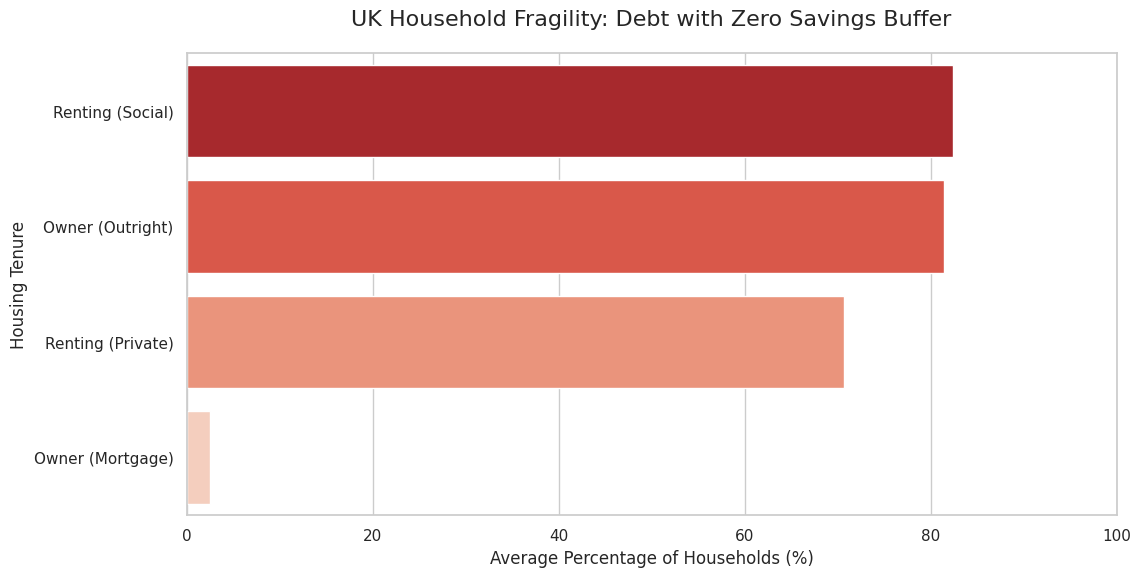

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the DataFrame is ready from your previous SQL result
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Aggregate fragility by tenure across both years
avg_fragility = df_resilience.groupby('tenure')['pct_fragile'].mean().sort_values(ascending=False).reset_index()

sns.barplot(
    data=avg_fragility, 
    x='pct_fragile', 
    y='tenure', 
    hue='tenure', 
    palette='Reds_r', 
    legend=False
)

plt.title('UK Household Fragility: Debt with Zero Savings Buffer', fontsize=16, pad=20)
plt.xlabel('Average Percentage of Households (%)', fontsize=12)
plt.ylabel('Housing Tenure', fontsize=12)
plt.xlim(0, 100)

plt.show()

_This chart identifies which housing groups in the UK are most vulnerable by calculating the percentage of households that carry debt but have zero savings buffer to fall back on._

### Key Findings
- **Social Tenure Vulnerability:** Social Renters (Council/Housing Association) are the most financially fragile group, with over **80%** of households carrying debt without any liquid savings.

- **High Fragility in Outright Ownership: Owner (Outright)** households show a nearly identical fragility level to social renters (**also above 80%**). This highlights a "cash poor" status despite owning an asset outright.

- **Private Rental Pressure:** Households in **Private Renting** also show high fragility, with approximately **70%** lacking a savings cushion.

- **Mortgage Resilience: Owner (Mortgage)** households are the most resilient, with only a small fraction (under **5%**) operating without a savings buffer.


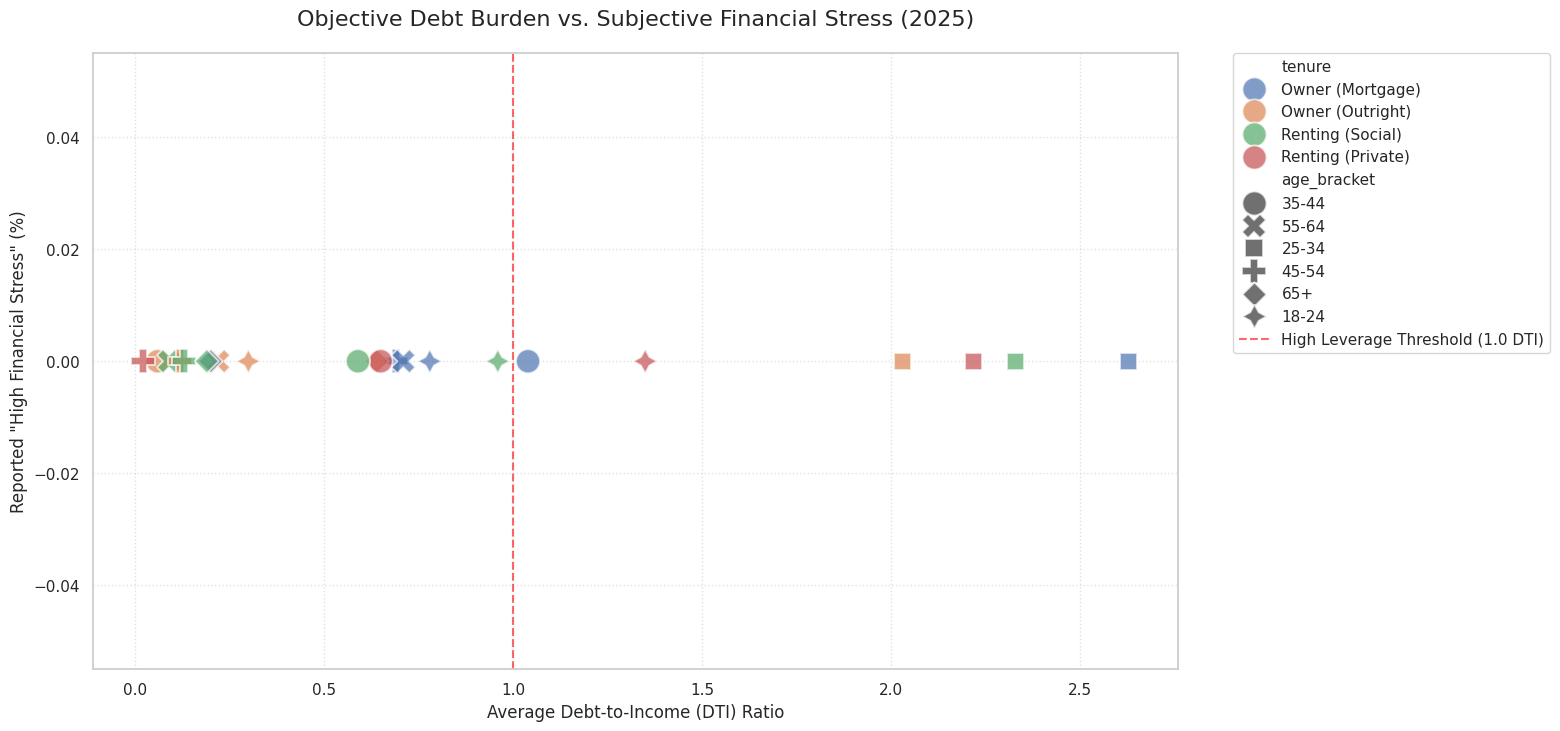

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# Filter for the most recent data (2025)
df_2025 = df_resilience[df_resilience['survey_year'] == 2025]

# Plot: Average DTI vs reported High Stress
# Note: Using s=300 for visibility and alpha=0.7 for overlapping points
sns.scatterplot(
    data=df_2025, 
    x='avg_dti', 
    y='pct_high_stress', 
    hue='tenure', 
    s=300, 
    alpha=0.7,
    style='age_bracket'
)

# Add a reference line at 1.0 DTI (Debt equals 100% of annual income)
plt.axvline(1.0, color='red', linestyle='--', alpha=0.6, label='High Leverage Threshold (1.0 DTI)')

plt.title('Objective Debt Burden vs. Subjective Financial Stress (2025)', fontsize=16, pad=20)
plt.xlabel('Average Debt-to-Income (DTI) Ratio', fontsize=12)
plt.ylabel('Reported "High Financial Stress" (%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

_This analysis compares the mathematical reality of debt (DTI) against how people actually feel (Reported High Stress)._

### Key Findings
- **The Total Disconnect:** Across every single demographic and tenure, the reported **"High Financial Stress" is 0%**

- **Living on Leverage:** A huge chunk of the groups surveyed have crossed the "danger zone" (the red dashed line), meaning they owe more than 100% of what they earn in a year.

- ** High Leverage normalization:** Multiple groups, particularly **25-34** year olds across different tenures, have Debt-to-Income (DTI) ratios far exceeding the **1.0 High Leverage Threshold**, yet still report no stress.

- **Extreme Outliers: The 25-34 Owner (Mortgage)** group shows the highest objective burden with a DTI over **2.5**, while still reporting 0% stress.


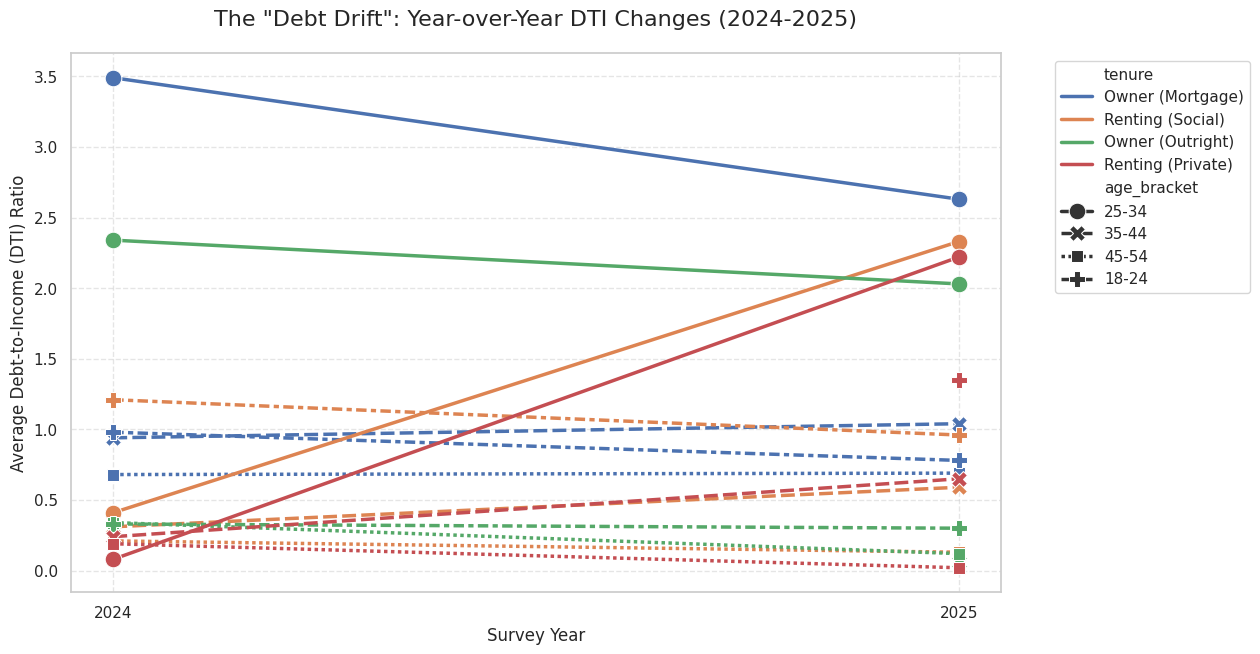

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# Focus on the most active working-age groups
drift_df = df_resilience[df_resilience['age_bracket'].isin(['18-24', '25-34', '35-44', '45-54'])]

# Plotting the trend from 2024 to 2025
sns.lineplot(
    data=drift_df, 
    x='survey_year', 
    y='avg_dti', 
    hue='tenure', 
    style='age_bracket',
    markers=True, 
    markersize=12,
    linewidth=2.5
)

plt.title('The "Debt Drift": Year-over-Year DTI Changes (2024-2025)', fontsize=16, pad=20)
plt.xlabel('Survey Year', fontsize=12)
plt.ylabel('Average Debt-to-Income (DTI) Ratio', fontsize=12)
plt.xticks([2024, 2025])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

_This line chart shows the speed at which debt-to-income ratios are shifting over a one-year period._

### Key Findings
- **The Rental Explosion:** The most dramatic upward trend is seen in **Renting (Social)** and **Renting (Private)** for the **25-34** age bracket. Their DTI ratios climbed from near **0.5** in 2024 to over **2.0** in 2025.

- **Mortgage De-leveraging:** Interestingly, the **25-34 Owner (Mortgage)** group saw their DTI **decrease** from a massive **3.5** in 2024 to approximately **2.6** in 2025.

- **Older Generation Stability:** DTI levels for the **45-54** and **18-24** brackets remained relatively flat and low (mostly under **1.0**) compared to the volatile middle-age groups.

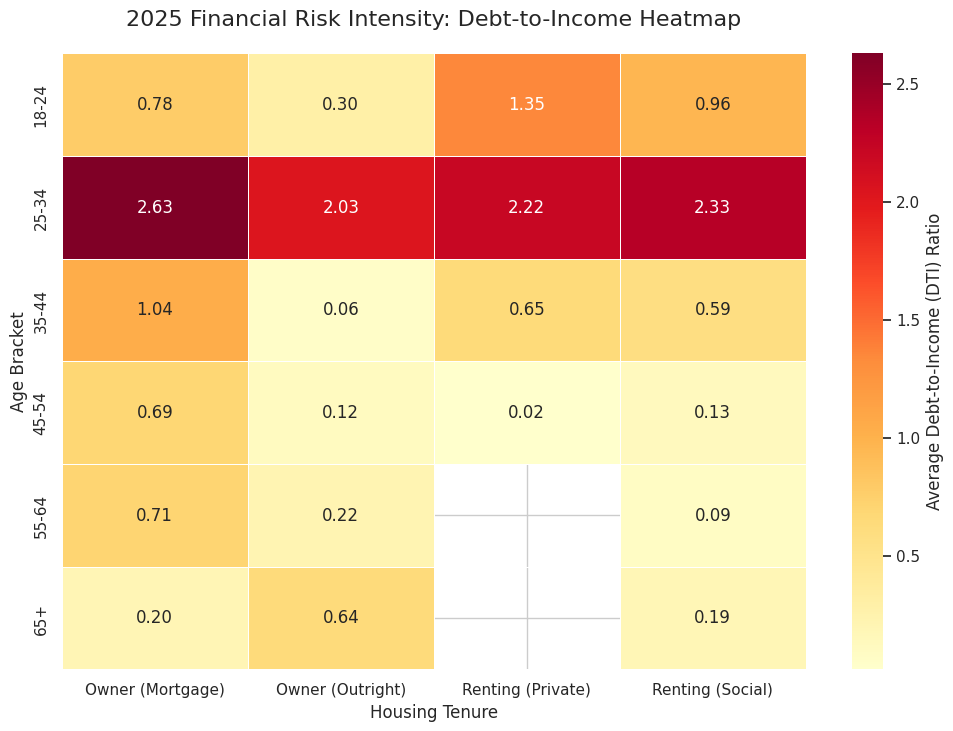

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Focus on the most recent 2025 data
df_2025 = df_resilience[df_resilience['survey_year'] == 2025]

# Create a pivot table for the heatmap
# Rows: Age Bracket | Columns: Housing Tenure | Values: Debt-to-Income (DTI)
risk_pivot = df_2025.pivot_table(
    index='age_bracket', 
    columns='tenure', 
    values='avg_dti'
)

# Plot the heatmap
sns.heatmap(
    risk_pivot, 
    annot=True, 
    cmap='YlOrRd', 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={'label': 'Average Debt-to-Income (DTI) Ratio'}
)

plt.title('2025 Financial Risk Intensity: Debt-to-Income Heatmap', fontsize=16, pad=20)
plt.xlabel('Housing Tenure', fontsize=12)
plt.ylabel('Age Bracket', fontsize=12)

plt.show()

_This heatmap shows where debt is most heavily concentrated by age and housing status in 2025._

### Key Findings
- **The 25-34 Risk Zone:** This age bracket is the "hottest" part of the map. Every housing tenure in this group has a DTI above **2.0**, with Mortgage holders at **2.63** and Social Renters at **2.33**.

- **Younger Renter Alert: 18-24 Private Renters** show a high intensity of 1.35, significantly higher than their peers who own outright (**0.30**).

- **The Stability Zone: The 45-54 Private Renters** represent the lowest risk on the map with a DTI of only **0.02**.

### The data reveals a massive _"Awareness Gap"_. While objective debt (DTI) is accelerating rapidly for young renters and remaining critically high for young homeowners, the subjective feeling of _"High Stress" is non-existent_ across the board. This suggests a dangerous normalization of high leverage in the 2025 UK economy.